In [ ]:
import pandas as pd
import boto3
import io
from sqlalchemy import create_engine

# 1. Parámetros de conexión
AWS_ACCESS_KEY = ''
AWS_SECRET_KEY = ''
BUCKET_NAME = ''

# USAMOS LA KEY EXACTA
KEY_HOUSING = ''

# Datos del RDS (SQL Server Express)
USER_RDS = ''
PASS_RDS = ''
ENDPOINT_RDS = ''
DB_NAME = ''

# 2. Extracción: De S3 a Python
print("Extrayendo archivo desde el Data Lake (S3)...")
s3 = boto3.client('s3', aws_access_key_id=AWS_ACCESS_KEY, aws_secret_access_key=AWS_SECRET_KEY)
obj = s3.get_object(Bucket=BUCKET_NAME, Key=KEY_HOUSING)
df_housing = pd.read_csv(io.BytesIO(obj['Body'].read()), encoding='utf-8')

# Diagnóstico de protocolo Patrick
print(f"\n--- CARGA EXITOSA: {len(df_housing)} registros encontrados ---")
print(df_housing.head())
print(df_housing.columns.tolist())

# 3. Carga: De Python a RDS (SQL Server)
print("\nIniciando transferencia a la base de datos en la nube...")
try:
    # Cadena de conexión para SQL Server
    engine = create_engine(f"mssql+pyodbc://{USER_RDS}:{PASS_RDS}@{ENDPOINT_RDS}:1433/{DB_NAME}?driver=ODBC+Driver+17+for+SQL+Server")
    
    # Inyecta los datos en el esquema
    df_housing.to_sql('kc_house', con=engine, schema='housing_analytics', if_exists='replace', index=False)
    print("--- PROCESO COMPLETADO: La data ya reside en RDS ---")
except Exception as e:
    print(f"Error en la carga a RDS: {e}")

Extrayendo archivo desde el Data Lake (S3)...

--- CARGA EXITOSA: 21613 registros encontrados ---
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Configura visualización técnica
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style="white")

# 1. Establece conexión con el Data Warehouse (RDS)
USER_RDS = ''
PASS_RDS = ''
ENDPOINT_RDS = ''
DB_NAME = ''

cadena_conexion = f""
engine = create_engine(cadena_conexion)

# 2. Extrae los datos mediante consulta SQL
query = "SELECT * FROM housing_analytics.kc_house;"
df_housing = pd.read_sql(query, engine)

# Ejecuta diagnóstico inicial
print("--- DATOS EXTRAÍDOS DESDE LA NUBE (AWS RDS) ---")
print(df_housing.head())
print(df_housing.columns.tolist())

--- DATOS EXTRAÍDOS DESDE LA NUBE (AWS RDS) ---
           id             date      price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000 221,900.00         3       1.00         1180   
1  6414100192  20141209T000000 538,000.00         3       2.25         2570   
2  5631500400  20150225T000000 180,000.00         2       1.00          770   
3  2487200875  20141209T000000 604,000.00         4       3.00         1960   
4  1954400510  20150218T000000 510,000.00         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650    1.00           0     0  ...      7        1180              0   
1      7242    2.00           0     0  ...      7        2170            400   
2     10000    1.00           0     0  ...      6         770              0   
3      5000    1.00           0     0  ...      7        1050            910   
4      8080    1.00           0     0  ...      8        1680              0 

In [3]:
# Calcula las magnitudes generales del negocio
total_propiedades = len(df_housing)
precio_medio = df_housing['price'].mean()
superficie_media = df_housing['sqft_living'].mean()

# Despliega el resumen ejecutivo
print("--- MAGNITUDES DEL NEGOCIO (KING COUNTY) ---")
print(f"Volumen Total del Portafolio: {total_propiedades:,.0f} propiedades")
print(f"Precio Promedio de Mercado: ${precio_medio:,.2f}")
print(f"Superficie Promedio Habitable: {superficie_media:,.2f} sqft")

--- MAGNITUDES DEL NEGOCIO (KING COUNTY) ---
Volumen Total del Portafolio: 21,613 propiedades
Precio Promedio de Mercado: $540,088.14
Superficie Promedio Habitable: 2,079.90 sqft


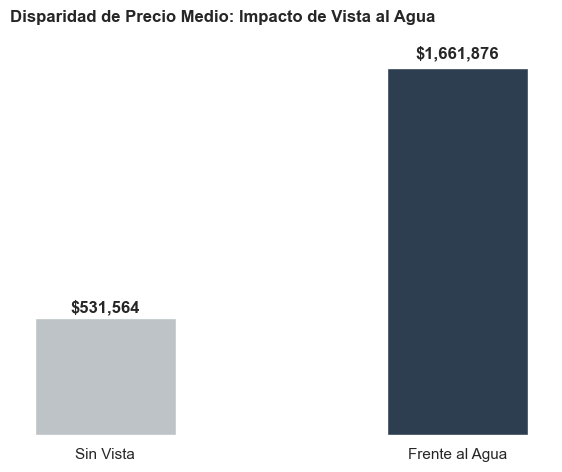

In [4]:
# Agrupa los datos según la variable waterfront
df_water = df_housing.groupby('waterfront')['price'].mean().reset_index()
df_water['Etiqueta'] = df_water['waterfront'].map({0: 'Sin Vista', 1: 'Frente al Agua'})

# Genera visualización comparativa
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(df_water['Etiqueta'], df_water['price'], color=['#bdc3c7', '#2c3e50'], width=0.4)

# Aplica limpieza visual 
sns.despine(left=True, bottom=True)
ax.get_yaxis().set_visible(False)

# Inserta etiquetas de datos directas
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'${yval:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.title('Disparidad de Precio Medio: Impacto de Vista al Agua', loc='left', fontweight='bold', pad=20)
plt.show()

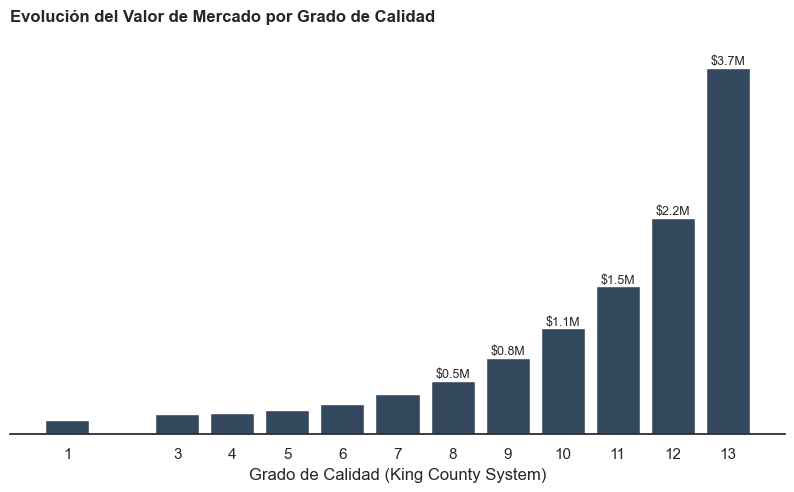

In [5]:
# Evalúa el precio promedio por grado de construcción
df_grade = df_housing.groupby('grade')['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_grade['grade'], df_grade['price'], color='#34495e')

sns.despine(left=True, bottom=False)
ax.get_yaxis().set_visible(False)
ax.set_xticks(df_grade['grade'])

for bar in bars:
    yval = bar.get_height()
    # Filtra etiquetas menores para mantener claridad en grados bajos
    if yval > 500000:
        ax.text(bar.get_x() + bar.get_width()/2, yval, f'${yval/1000000:,.1f}M', ha='center', va='bottom', fontsize=9)

plt.title('Evolución del Valor de Mercado por Grado de Calidad', loc='left', fontweight='bold', pad=20)
plt.xlabel('Grado de Calidad (King County System)')
plt.show()

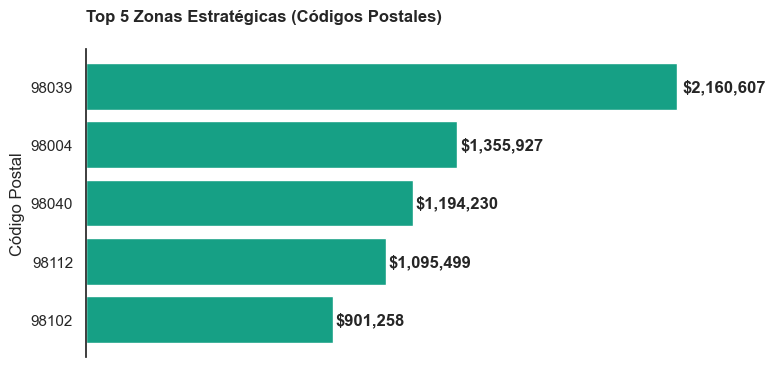

In [6]:
# Identifica los códigos postales con mayor precio promedio
df_zip = df_housing.groupby('zipcode')['price'].mean().sort_values(ascending=False).head(5).reset_index()
df_zip['zipcode'] = df_zip['zipcode'].astype(str)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_zip['zipcode'], df_zip['price'], color='#16a085')
ax.invert_yaxis()

sns.despine(left=False, bottom=True)
ax.get_xaxis().set_visible(False)

for bar in bars:
    xval = bar.get_width()
    ax.text(xval + (xval*0.01), bar.get_y() + bar.get_height()/2, f'${xval:,.0f}', ha='left', va='center', fontweight='bold')

plt.title('Top 5 Zonas Estratégicas (Códigos Postales)', loc='left', fontweight='bold', pad=20)
plt.ylabel('Código Postal')
plt.show()

In [7]:
import os

# Define la ruta de salida
ruta_salida = os.path.join(r'C:\Users\patri\Downloads', 'dashboard_ebac.html')

# Genera el contenido HTML con diseño limpio y Chart.js para la gráfica
html_content = """
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>Housing Analytics</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #fdfbf7; color: #333; margin: 0; padding: 20px; }
        .container { max-width: 1200px; margin: auto; }
        .header { border-bottom: 2px solid #2c3e50; padding-bottom: 10px; margin-bottom: 20px; }
        h1 { color: #2c3e50; margin: 0; font-size: 24px; text-transform: uppercase; }
        p.subtitle { color: #7f8c8d; margin: 5px 0 0 0; font-size: 14px; }
        
        .filters { display: flex; gap: 20px; margin-bottom: 30px; }
        .filter-box { display: flex; flex-direction: column; width: 200px; }
        .filter-box label { font-size: 12px; font-weight: bold; color: #34495e; margin-bottom: 5px; }
        .filter-box select { padding: 8px; border: 1px solid #bdc3c7; border-radius: 4px; }

        .kpi-container { display: flex; gap: 20px; margin-bottom: 40px; }
        .kpi-card { background-color: #ecf0f1; padding: 20px; border-radius: 6px; flex: 1; border-left: 4px solid #2c3e50; }
        .kpi-title { font-size: 13px; color: #7f8c8d; font-weight: bold; text-transform: uppercase; }
        .kpi-value { font-size: 28px; color: #2c3e50; font-weight: bold; margin: 10px 0; }
        .kpi-desc { font-size: 11px; color: #7f8c8d; }

        .chart-container { background: white; padding: 20px; border: 1px solid #ecf0f1; border-radius: 6px; }
        .footer { margin-top: 40px; font-size: 11px; color: #95a5a6; text-align: left; }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>King County Housing Analytics</h1>
            <p class="subtitle">Visión Ejecutiva del Mercado Inmobiliario - Formato: Mes, Día, Año</p>
        </div>

        <div class="filters">
            <div class="filter-box">
                <label>Filtro: Código Postal</label>
                <select><option>Todos los códigos</option><option>98178</option><option>98125</option></select>
            </div>
            <div class="filter-box">
                <label>Filtro: Condición</label>
                <select><option>Todas</option><option>Excelente</option><option>Buena</option></select>
            </div>
            <div class="filter-box">
                <label>Filtro: Grado de Calidad</label>
                <select><option>Todos los grados</option><option>G10 Premium</option></select>
            </div>
        </div>

        <div class="kpi-container">
            <div class="kpi-card">
                <div class="kpi-title">Volumen Total</div>
                <div class="kpi-value">21,613</div>
                <div class="kpi-desc">Propiedades analizadas en el condado</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-title">Precio Promedio</div>
                <div class="kpi-value">$540,088</div>
                <div class="kpi-desc">Valor medio de venta (USD)</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-title">Superficie Media</div>
                <div class="kpi-value">2,080</div>
                <div class="kpi-desc">Metros cuadrados habitables (sqft)</div>
            </div>
        </div>

        <div class="chart-container">
            <h2 style="font-size: 16px; color:#2c3e50; margin-top:0;">Evolución del Precio Medio por Grado de Calidad</h2>
            <canvas id="myChart" height="80"></canvas>
        </div>

        <div class="footer">
            Fuente de Datos: Data Warehouse AWS RDS (housing_analytics) | Página: Resumen General
        </div>
    </div>

    <script>
        const ctx = document.getElementById('myChart').getContext('2d');
        new Chart(ctx, {
            type: 'bar',
            data: {
                labels: ['Grado 6', 'Grado 7', 'Grado 8', 'Grado 9', 'Grado 10', 'Grado 11', 'Grado 12'],
                datasets: [{
                    label: 'Precio Medio ($)',
                    data: [301159, 402590, 542852, 887048, 1071347, 1496842, 2191222],
                    backgroundColor: '#34495e'
                }]
            },
            options: {
                responsive: true,
                plugins: { legend: { display: false } },
                scales: {
                    y: { beginAtZero: true, grid: { color: '#ecf0f1' } },
                    x: { grid: { display: false } }
                }
            }
        });
    </script>
</body>
</html>
"""

# Escribe el archivo en formato utf-8
with open(ruta_salida, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"Página web local creada con éxito en: {ruta_salida}")

Página web local creada con éxito en: C:\Users\patri\Downloads\dashboard_ebac.html


In [8]:
import os
from fpdf import FPDF
import warnings

# Suprime advertencias estéticas de la librería
warnings.filterwarnings("ignore", category=DeprecationWarning)

class PDFReport(FPDF):
    def header(self):
        # Establece el encabezado corporativo
        self.set_font('helvetica', 'B', 15)
        self.set_fill_color(34, 49, 63)
        self.set_text_color(255, 255, 255)
        self.cell(0, 15, ' Práctica M54: Arquitectura Cloud y Análisis de Datos', border=0, 
                  new_x="LMARGIN", new_y="NEXT", align='L', fill=True)
        self.ln(5)

    def footer(self):
        # Establece el pie de página
        self.set_y(-15)
        self.set_font('helvetica', 'I', 8)
        self.set_text_color(128, 128, 128)
        self.cell(0, 10, f'Autor: Patrick - EBAC | Análisis Cloud | Página {self.page_no()}', align='C')

def compila_reporte_analitico():
    # Define la ruta base según entorno
    ruta_base = r'C:\Users\patri\Downloads'
    
    # Inicializa el documento
    pdf = PDFReport()
    pdf.set_auto_page_break(auto=True, margin=15)
    
    # Estructura el contenido: (Archivo, Título, Insight)
    diapositivas = [
        ("c1.png", "1. Almacenamiento en Data Lake (Amazon S3)", 
         "Los archivos crudos se han depositado en la zona raw del bucket S3, estableciendo la capa de bronce de nuestra arquitectura cloud."),
        ("c2.png", "2. Conexión a Infraestructura AWS", 
         "Establecimiento del puente de red hacia el endpoint de la instancia RDS, asegurando los accesos y credenciales IAM correspondientes."),
        ("c3.png", "3. Persistencia y Estructuración (SQL Server)", 
         "Aplicación de la lógica IF EXISTS para evitar conflictos, seguida de la creación de la base de datos 'HousingDB' y su esquema analítico dedicado."),
        ("c4.png", "4. Proceso ETL mediante Python", 
         "Extracción del archivo desde S3 a memoria, y posterior inserción masiva a la tabla estructurada en SQL Server a través de SQLAlchemy."),
        ("c5.png", "5. Validación de Datos en la Nube", 
         "Diagnóstico post-carga ejecutando consultas directas sobre la base de datos RDS, asegurando que los datos operan 100% en la nube."),
        ("c6.png", "6. Magnitudes del Negocio (KPIs)", 
         "Las métricas extraídas brindan una dimensión inmediata del mercado: un portafolio robusto con un precio medio superior a los $500 mil dólares."),
        ("c7.png", "7. Impacto de Valoración: Waterfront", 
         "El análisis revela una prima de precio sustancial. Las propiedades con vista al agua multiplican su valor de mercado frente a las estándar."),
        ("c8.png", "8. Evolución de Precio por Calidad (Grade)", 
         "Se identifica una escalabilidad exponencial en el precio a partir del grado 8. La calidad constructiva dicta el salto hacia propiedades premium."),
        ("c9.png", "9. Top 5 Códigos Postales Estratégicos", 
         "Mapeo de los sectores geográficos de mayor plusvalía, vitales para focalizar esfuerzos de adquisición o desarrollo inmobiliario de alto nivel."),
        ("c10.png", "10. Propuesta de Dashboard Web", 
         "Prototipo de interfaz implementando estándares de comunicación limpia (IBCS). Incluye filtros dinámicos, KPIs globales y la gráfica principal de mercado.")
    ]

    imagenes_procesadas = 0

    # Recorre las diapositivas para armar el documento
    for archivo, titulo, insight in diapositivas:
        ruta_completa = os.path.join(ruta_base, archivo)
        
        if os.path.exists(ruta_completa):
            pdf.add_page()
            
            # Inserta el título
            pdf.set_font('helvetica', 'B', 13)
            pdf.set_text_color(44, 62, 80)
            pdf.cell(0, 10, titulo, new_x="LMARGIN", new_y="NEXT")
            
            # Inserta el insight / texto explicativo
            pdf.set_font('helvetica', '', 11)
            pdf.set_text_color(80, 80, 80)
            pdf.multi_cell(0, 7, insight)
            pdf.ln(5)
            
            # Inserta la captura de pantalla ajustada
            ancho_util = pdf.epw
            pdf.image(ruta_completa, x=15, w=ancho_util)
            
            imagenes_procesadas += 1
        else:
            print(f"Advertencia: Falta la imagen '{archivo}' en Descargas.")

    # Consolida el documento si hay imágenes
    if imagenes_procesadas > 0:
        ruta_salida = os.path.join(ruta_base, 'Practica_M54_Reporte_Final.pdf')
        pdf.output(ruta_salida)
        print(f"\nReporte final compilado exitosamente.")
        print(f"Total de diapositivas procesadas: {imagenes_procesadas}/10")
        print(f"Archivo listo en: {ruta_salida}")
    else:
        print("\nError: No se encontró ninguna imagen en la ruta base para generar el PDF.")

# Ejecuta la compilación
compila_reporte_analitico()


Reporte final compilado exitosamente.
Total de diapositivas procesadas: 10/10
Archivo listo en: C:\Users\patri\Downloads\Practica_M54_Reporte_Final.pdf
